In [12]:
import sys
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "src")

from dengue_forecast.evaluate import run_backtest
from dengue_forecast.models import (
    SarimaxForecaster,
    catboost_forecaster,
    randomforest_forecaster,
    xgboost_forecaster,
)

# LightGBM é opcional, pois no macOS pode exigir libomp.
try:
    from dengue_forecast.models import lgbm_forecaster
    HAS_LIGHTGBM = True
except Exception as e:
    print("LightGBM indisponível:", e)
    HAS_LIGHTGBM = False


HORIZON = 12
MIN_TRAIN = 48
LAGS = 24

DATA_DIR = Path("data/processed")
RESULTS_DIR = Path('results')
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "comparisons"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)


CITY_META = {
    "sao": {"city": "São Paulo", "state": "SP", "region": "Southeast"},
    "sao_paulo": {"city": "São Paulo", "state": "SP", "region": "Southeast"},
    "rio": {"city": "Rio de Janeiro", "state": "RJ", "region": "Southeast"},
    "rio_de_janeiro": {"city": "Rio de Janeiro", "state": "RJ", "region": "Southeast"},
    "belo_horizonte": {"city": "Belo Horizonte", "state": "MG", "region": "Southeast"},
    "brasilia": {"city": "Brasília", "state": "DF", "region": "Midwest"},
    "fortaleza": {"city": "Fortaleza", "state": "CE", "region": "Northeast"},
    "recife": {"city": "Recife", "state": "PE", "region": "Northeast"},
    "manaus": {"city": "Manaus", "state": "AM", "region": "North"},
    "salvador": {"city": "Salvador", "state": "BA", "region": "Northeast"},
}


def slug_from_path(path):
    name = path.stem
    name = name.replace("dengue_monthly_", "")
    name = name.replace("dengue_", "")
    name = name.replace("_2010_2024", "")
    return name


def load_series(path):
    df = pd.read_csv(path)

    date_col = "date" if "date" in df.columns else df.columns[0]
    value_col = "value" if "value" in df.columns else df.columns[-1]

    df[date_col] = pd.to_datetime(df[date_col])
    series = (
        df.sort_values(date_col)
        .set_index(date_col)[value_col]
        .asfreq("MS")
        .astype(float)
    )

    return series


def make_models():
    models = [
        SarimaxForecaster(order=(1, 1, 1), seasonal_order=(1, 1, 0, 12)),
        xgboost_forecaster(lags=LAGS),
        catboost_forecaster(lags=LAGS),
        randomforest_forecaster(lags=LAGS),
    ]

    if HAS_LIGHTGBM:
        models.insert(1, lgbm_forecaster(lags=LAGS))

    return models


def benchmark_series(series, unit_name, state=None, region=None, level="city"):
    metrics_rows = []
    preds_frames = []

    for model in make_models():
        print(f"Rodando {model.name} — {unit_name}")

        try:
            metric_row, pred_df = run_backtest(
                series=series,
                model=model,
                horizon=HORIZON,
                min_train_size=MIN_TRAIN,
            )

            if metric_row is not None:
                metric_row = dict(metric_row)
                metric_row["unit"] = unit_name
                metric_row["state"] = state
                metric_row["region"] = region
                metric_row["level"] = level
                metrics_rows.append(metric_row)

            if pred_df is not None and not pred_df.empty:
                pred_df = pred_df.copy()
                pred_df["unit"] = unit_name
                pred_df["state"] = state
                pred_df["region"] = region
                pred_df["level"] = level
                preds_frames.append(pred_df)

        except Exception as e:
            print(f"Falha em {model.name} — {unit_name}: {e}")

    metrics_df = pd.DataFrame(metrics_rows)
    preds_df = pd.concat(preds_frames, ignore_index=True) if preds_frames else pd.DataFrame()

    return metrics_df, preds_df


all_metrics = []
all_preds = []
series_registry = {}

csv_files = sorted(DATA_DIR.glob("*.csv"))

for path in csv_files:
    slug = slug_from_path(path)
    meta = CITY_META.get(
        slug,
        {"city": slug.replace("_", " ").title(), "state": None, "region": None}
    )

    series = load_series(path)
    series_registry[meta["city"]] = {
        "series": series,
        "state": meta["state"],
        "region": meta["region"],
    }

    metrics_df, preds_df = benchmark_series(
        series=series,
        unit_name=meta["city"],
        state=meta["state"],
        region=meta["region"],
        level="city",
    )

    all_metrics.append(metrics_df)
    all_preds.append(preds_df)


metrics_all = pd.concat(all_metrics, ignore_index=True)
preds_all = pd.concat(all_preds, ignore_index=True)

metrics_all = metrics_all.rename(
    columns={
        "mae": "MAE",
        "rmse": "RMSE",
        "smape": "sMAPE",
        "n_predictions": "n_previsoes",
        "n_previsoes": "n_previsoes",
    }
)

metrics_all["rank_sMAPE"] = (
    metrics_all.groupby(["level", "unit"])["sMAPE"]
    .rank(method="min")
)

metrics_all.to_csv(TABLES_DIR / "model_performance_all_cities_long.csv", index=False)
preds_all.to_csv(TABLES_DIR / "predictions_all_cities_long.csv", index=False)

metrics_all.sort_values(["unit", "sMAPE"]).head()

Rodando sarimax — Belo
  [INFO] Rodando backtest para: sarimax


KeyboardInterrupt: 

Tabela comparativa única (cidade-estado-modelo)

In [6]:
performance_table = (
    metrics_all
    .sort_values(["state", "unit", "sMAPE"])
    [["level", "region", "state", "unit", "model", "MAE", "RMSE", "sMAPE", "n_previsoes", "rank_sMAPE"]]
)

performance_table.to_csv(TABLES_DIR / "model_performance_by_state_city_model.csv", index=False)

performance_table

,level,region,state,unit,model,MAE,RMSE,sMAPE,n_previsoes,rank_sMAPE
17,city,North,AM,Manaus,xgboost,324.298380,505.928031,65.481193,1452,1.0
19,city,North,AM,Manaus,randomforest,328.298044,505.844263,67.865818,1452,2.0
18,city,North,AM,Manaus,catboost,348.523485,541.731627,70.932050,1452,3.0
16,city,North,AM,Manaus,lgbm,523.883142,699.992036,94.803466,1452,4.0
15,city,North,AM,Manaus,sarimax,352.916742,604.632363,99.727284,1452,5.0
32,city,Northeast,BA,Salvador,xgboost,508.490356,802.553150,72.080767,1452,1.0
34,city,Northeast,BA,Salvador,randomforest,513.834621,762.439911,73.720194,1452,2.0
33,city,Northeast,BA,Salvador,catboost,489.894230,731.487103,76.040179,1452,3.0
31,city,Northeast,BA,Salvador,lgbm,554.054387,749.928885,82.160369,1452,4.0
30,city,Northeast,BA,Salvador,sarimax,566.660704,906.847859,90.976035,1452,5.0


Tabela pivot p o artigo

In [7]:
pivot_smape = performance_table.pivot_table(
    index=["region", "state", "unit"],
    columns="model",
    values="sMAPE",
    aggfunc="first"
).reset_index()

pivot_mae = performance_table.pivot_table(
    index=["region", "state", "unit"],
    columns="model",
    values="MAE",
    aggfunc="first"
).reset_index()

pivot_rmse = performance_table.pivot_table(
    index=["region", "state", "unit"],
    columns="model",
    values="RMSE",
    aggfunc="first"
).reset_index()

pivot_smape.to_csv(TABLES_DIR / "pivot_smape_by_state_city.csv", index=False)
pivot_mae.to_csv(TABLES_DIR / "pivot_mae_by_state_city.csv", index=False)
pivot_rmse.to_csv(TABLES_DIR / "pivot_rmse_by_state_city.csv", index=False)

pivot_smape

model,region,state,unit,catboost,lgbm,randomforest,sarimax,xgboost
0,Midwest,DF,Brasília,76.620848,100.549926,82.384841,103.162274,83.741951
1,North,AM,Manaus,70.932050,94.803466,67.865818,99.727284,65.481193
2,Northeast,BA,Salvador,76.040179,82.160369,73.720194,90.976035,72.080767
3,Northeast,CE,Fortaleza,77.541719,102.078989,98.399144,87.607314,89.373053
4,Northeast,PE,Recife,83.251779,111.157023,81.221688,105.647876,83.301777
5,Southeast,RJ,Rio de Janeiro,126.410490,154.664930,133.272061,135.568239,119.675684
6,Southeast,SP,São Paulo,78.739832,119.794586,87.329256,87.055332,84.849679


métricas p/ cidade

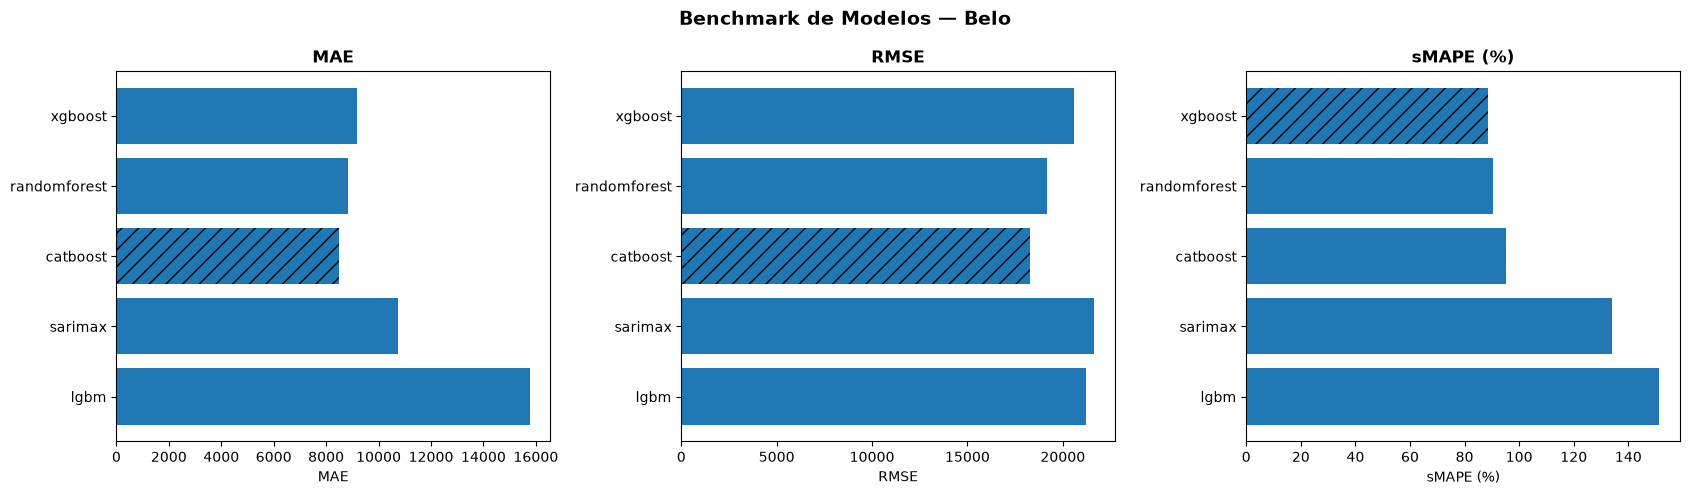

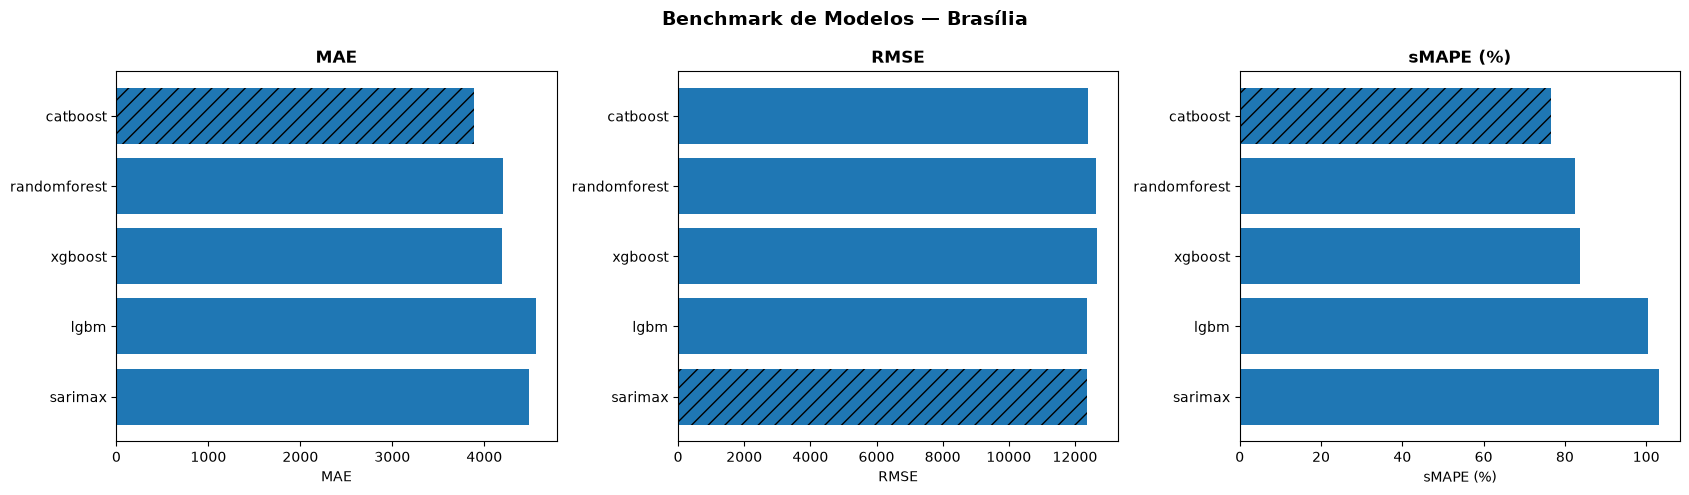

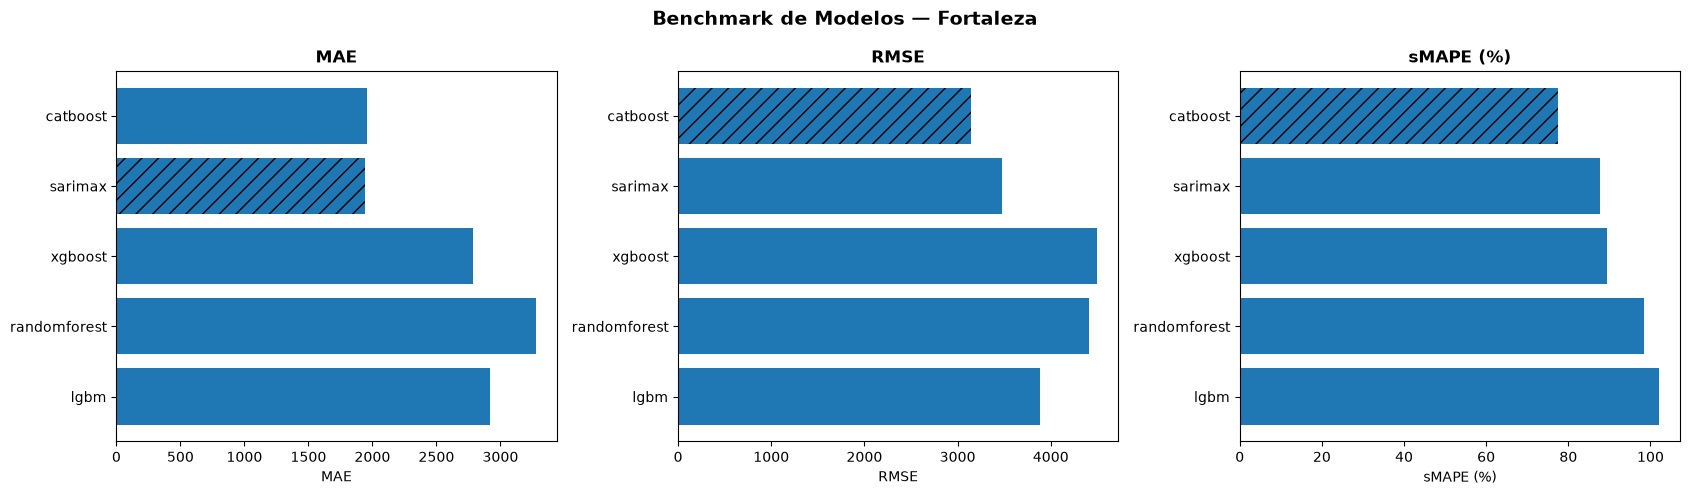

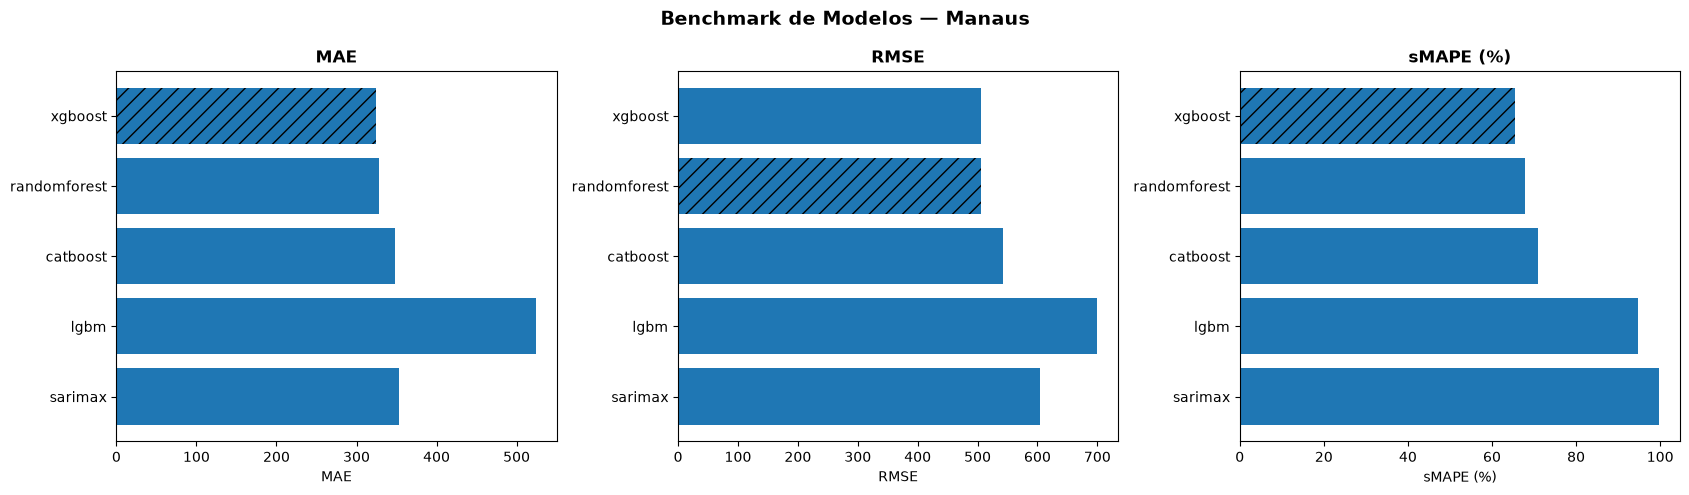

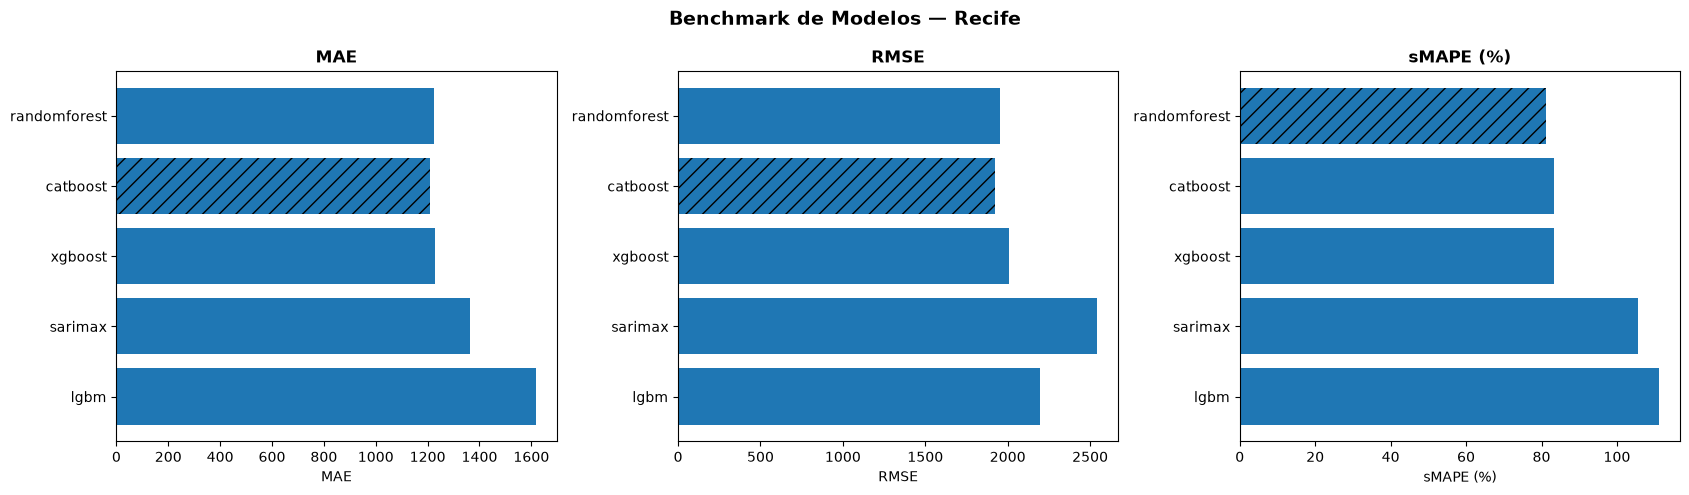

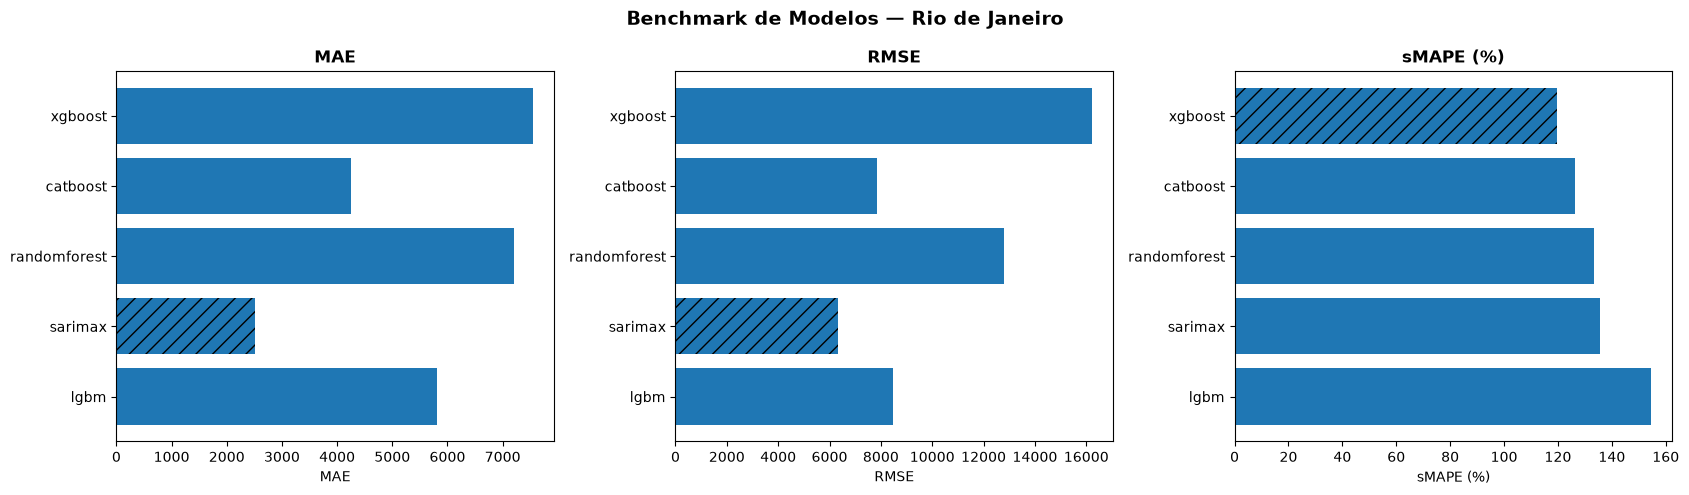

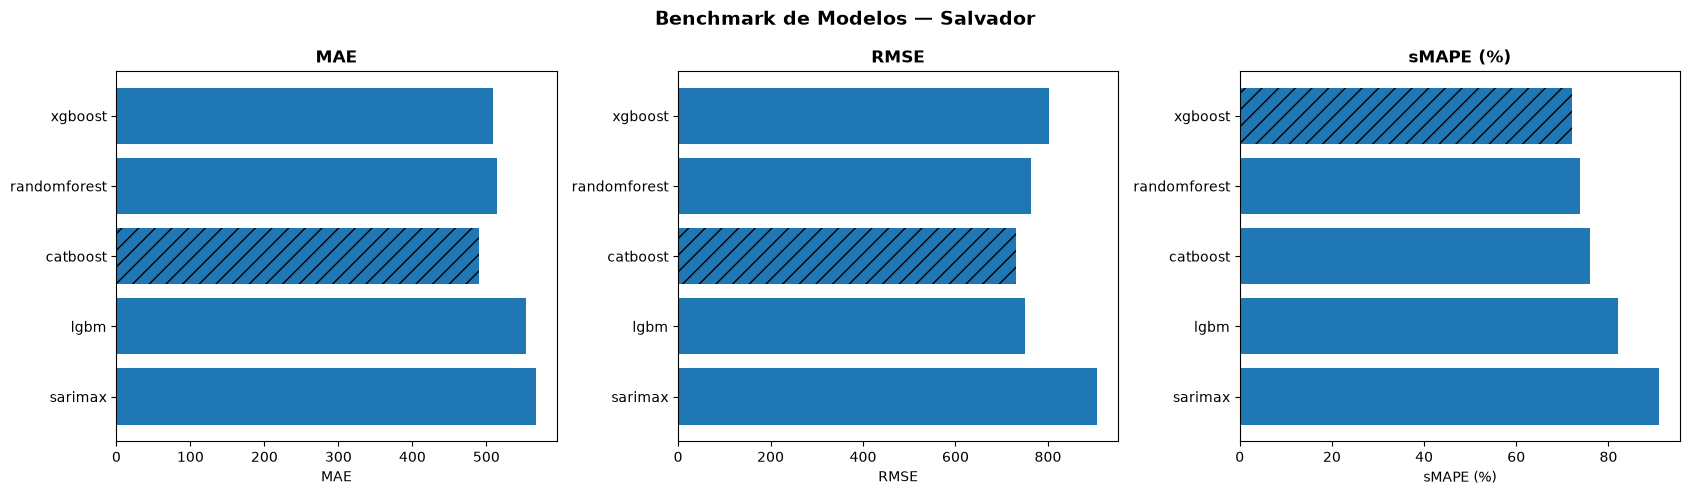

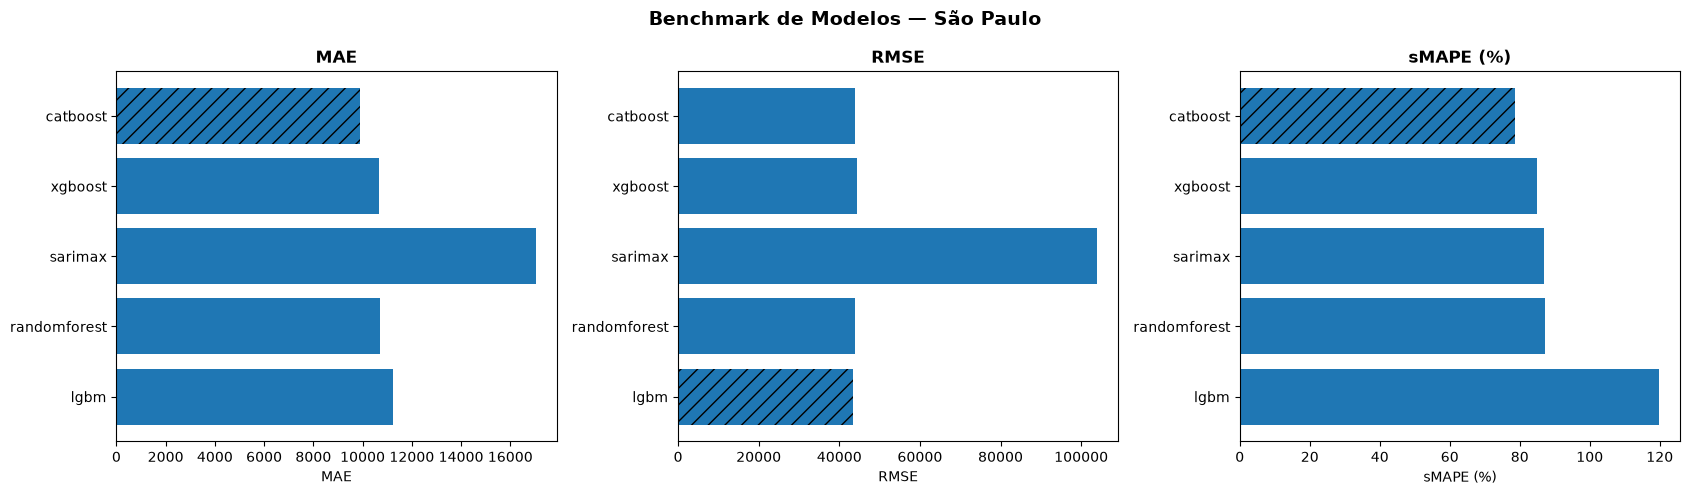

In [8]:
def plot_metrics_for_unit(metrics_all, unit_name, output_dir=FIGURES_DIR):
    sub = metrics_all[metrics_all["unit"] == unit_name].sort_values("sMAPE")

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    metric_specs = [
        ("MAE", "MAE"),
        ("RMSE", "RMSE"),
        ("sMAPE", "sMAPE (%)"),
    ]

    for ax, (col, label) in zip(axes, metric_specs):
        values = sub[col].values
        models = sub["model"].values

        bars = ax.barh(models, values)
        ax.invert_yaxis()
        ax.set_xlabel(label)
        ax.set_title(label, fontweight="bold")

        best_idx = int(np.nanargmin(values))
        bars[best_idx].set_hatch("//")

    fig.suptitle(f"Benchmark de Modelos — {unit_name}", fontsize=14, fontweight="bold")
    plt.tight_layout()

    safe_name = re.sub(r"[^a-zA-Z0-9]+", "_", unit_name.lower()).strip("_")
    path = output_dir / f"metrics_{safe_name}.png"
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()

    return path


for unit in sorted(metrics_all["unit"].dropna().unique()):
    plot_metrics_for_unit(metrics_all, unit)
    

Graph do real vs predito p cada cidade

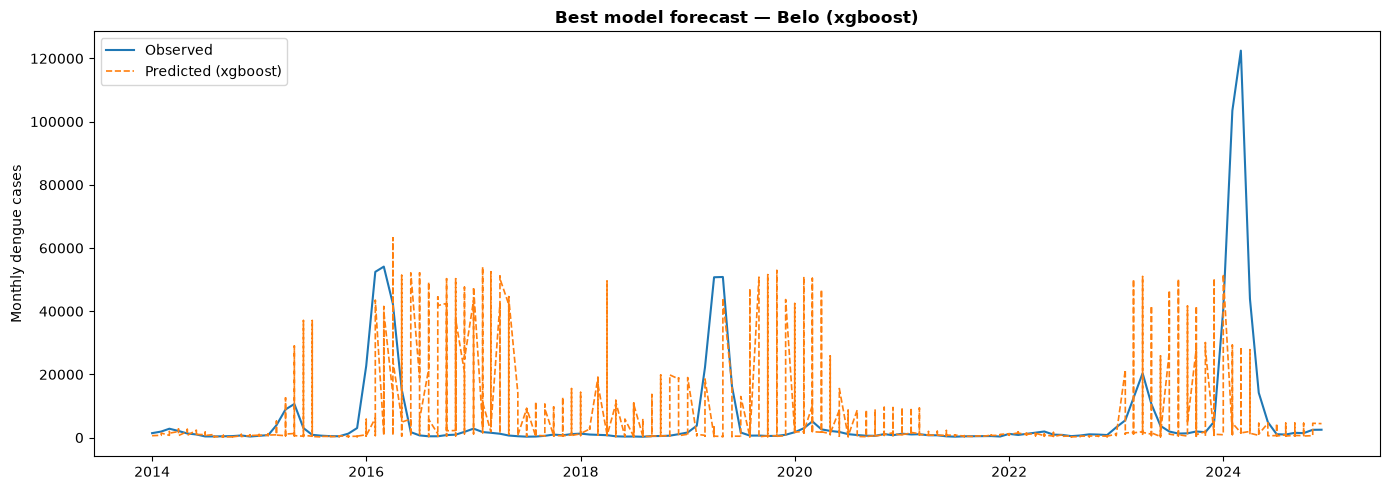

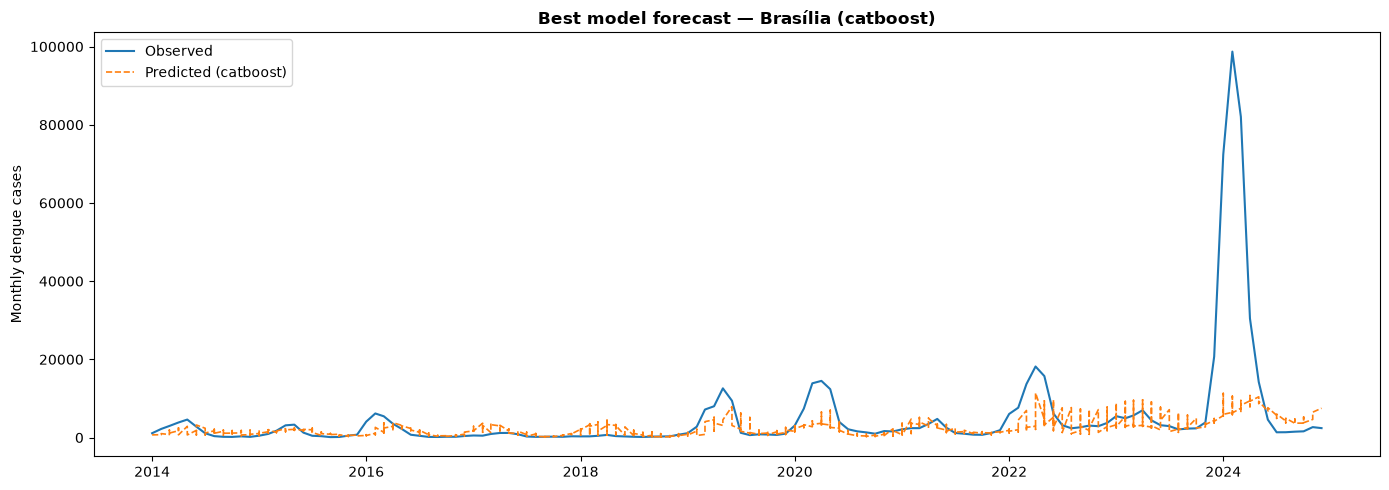

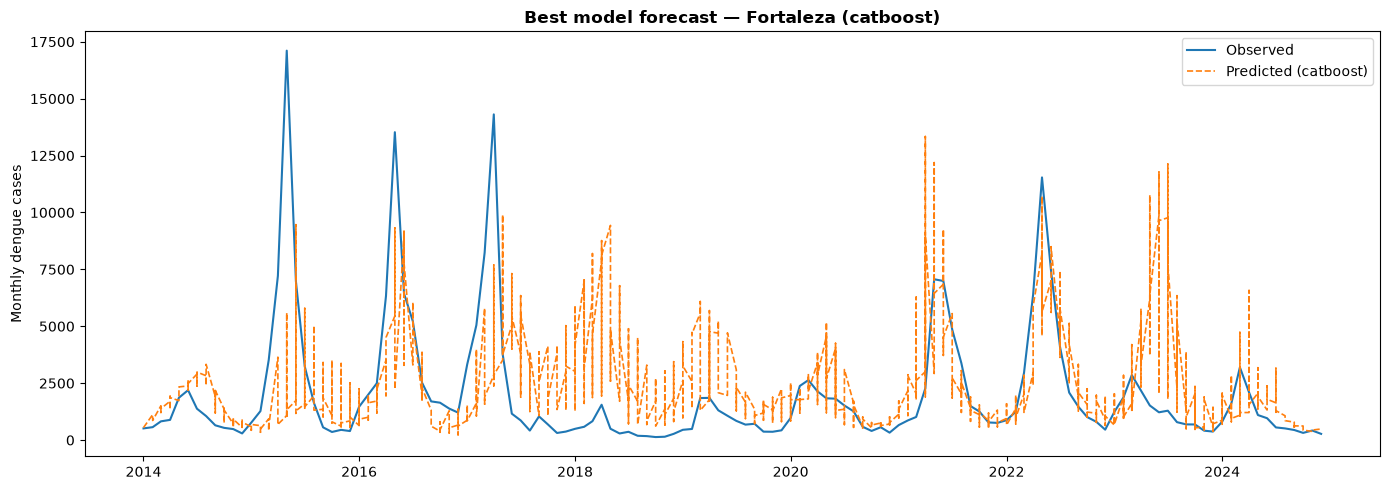

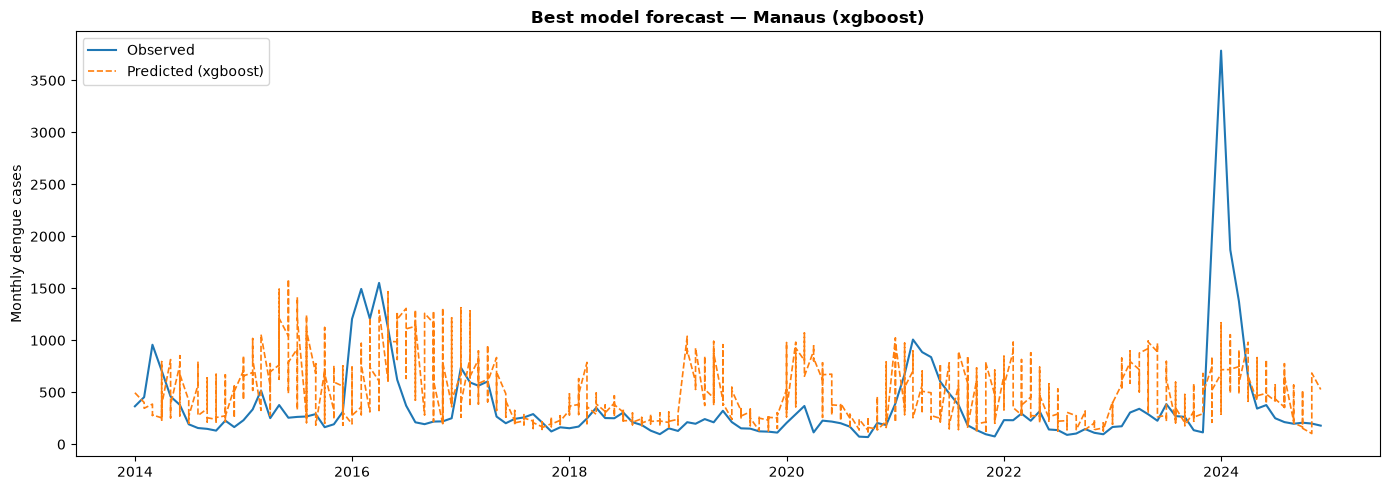

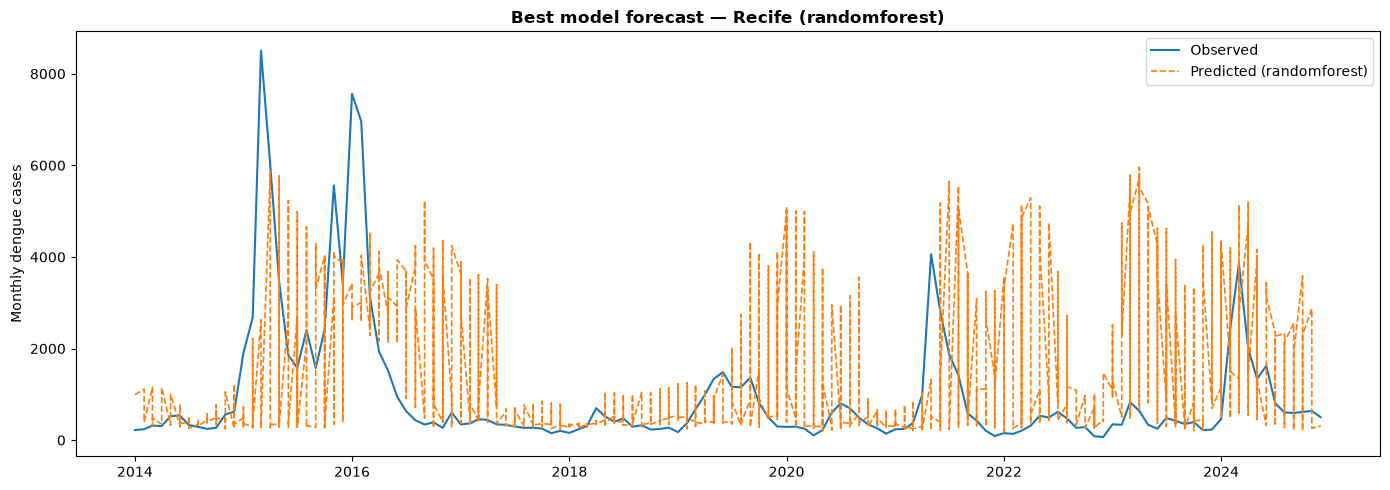

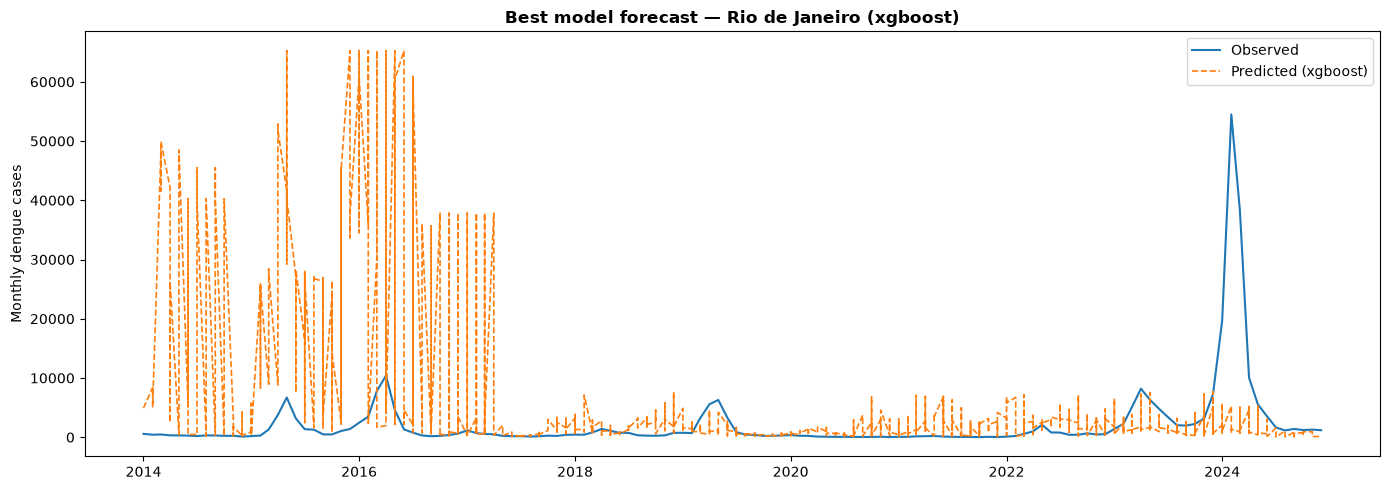

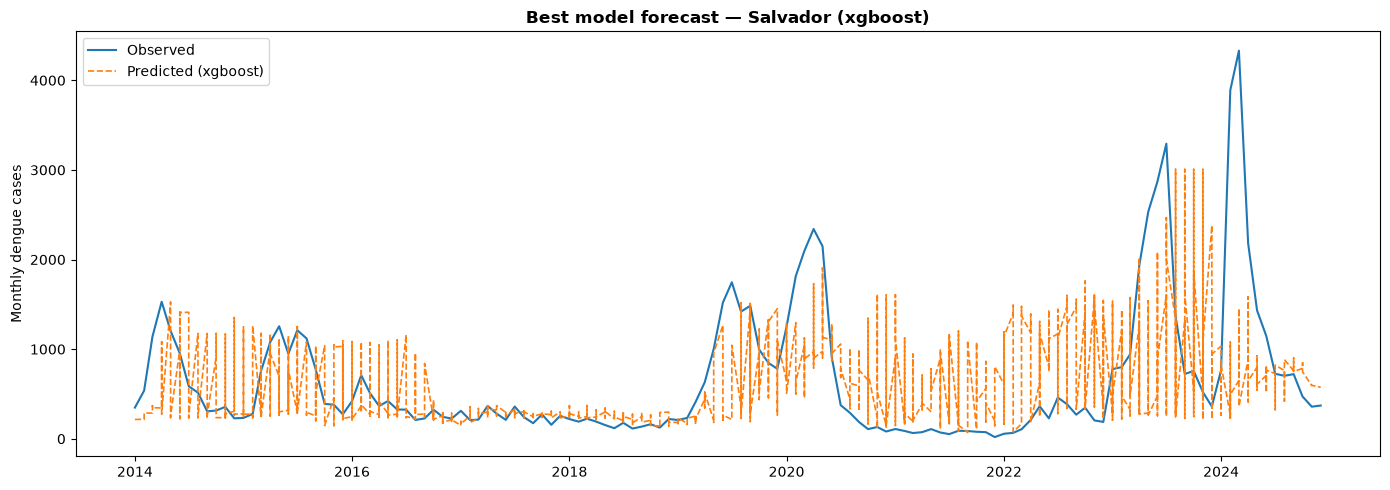

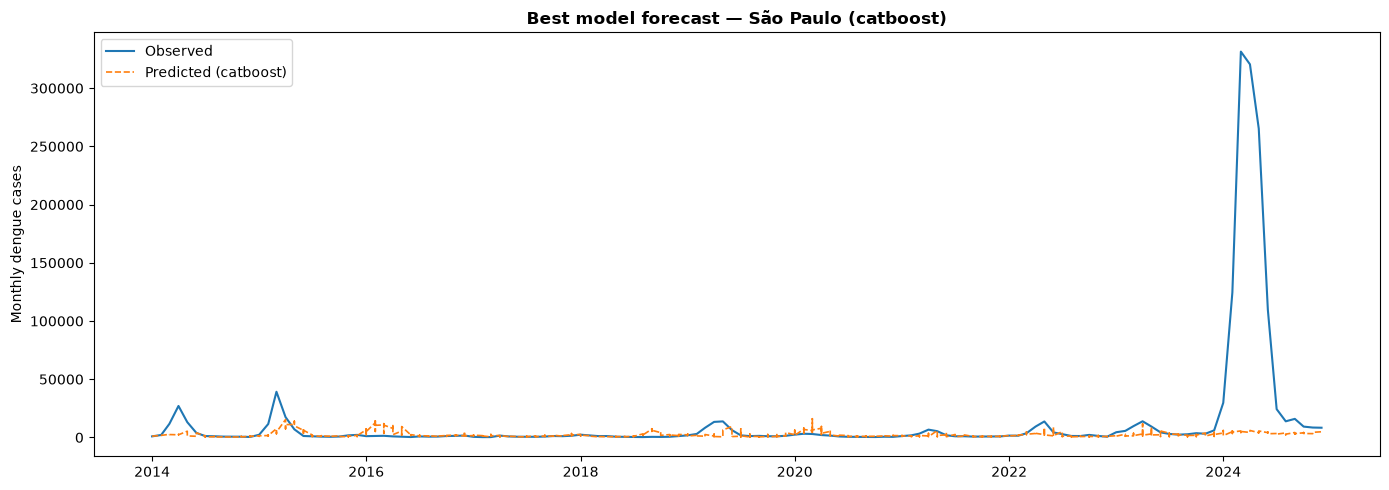

In [9]:
def plot_best_forecast_for_unit(metrics_all, preds_all, unit_name, output_dir=FIGURES_DIR):
    best_model = (
        metrics_all[metrics_all["unit"] == unit_name]
        .sort_values("sMAPE")
        .iloc[0]["model"]
    )

    sub = (
        preds_all[
            (preds_all["unit"] == unit_name) &
            (preds_all["model"] == best_model)
        ]
        .copy()
        .sort_values("date")
    )

    sub["date"] = pd.to_datetime(sub["date"])

    plt.figure(figsize=(14, 5))
    plt.plot(sub["date"], sub["y_true"], label="Observed", linewidth=1.5)
    plt.plot(sub["date"], sub["y_pred"], label=f"Predicted ({best_model})", linestyle="--", linewidth=1.2)

    plt.title(f"Best model forecast — {unit_name} ({best_model})", fontweight="bold")
    plt.ylabel("Monthly dengue cases")
    plt.legend()
    plt.tight_layout()

    safe_name = re.sub(r"[^a-zA-Z0-9]+", "_", unit_name.lower()).strip("_")
    path = output_dir / f"forecast_best_model_{safe_name}.png"
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()

    return path


for unit in sorted(metrics_all["unit"].dropna().unique()):
    plot_best_forecast_for_unit(metrics_all, preds_all, unit)

2x4 do melhor modelo de cada cidade

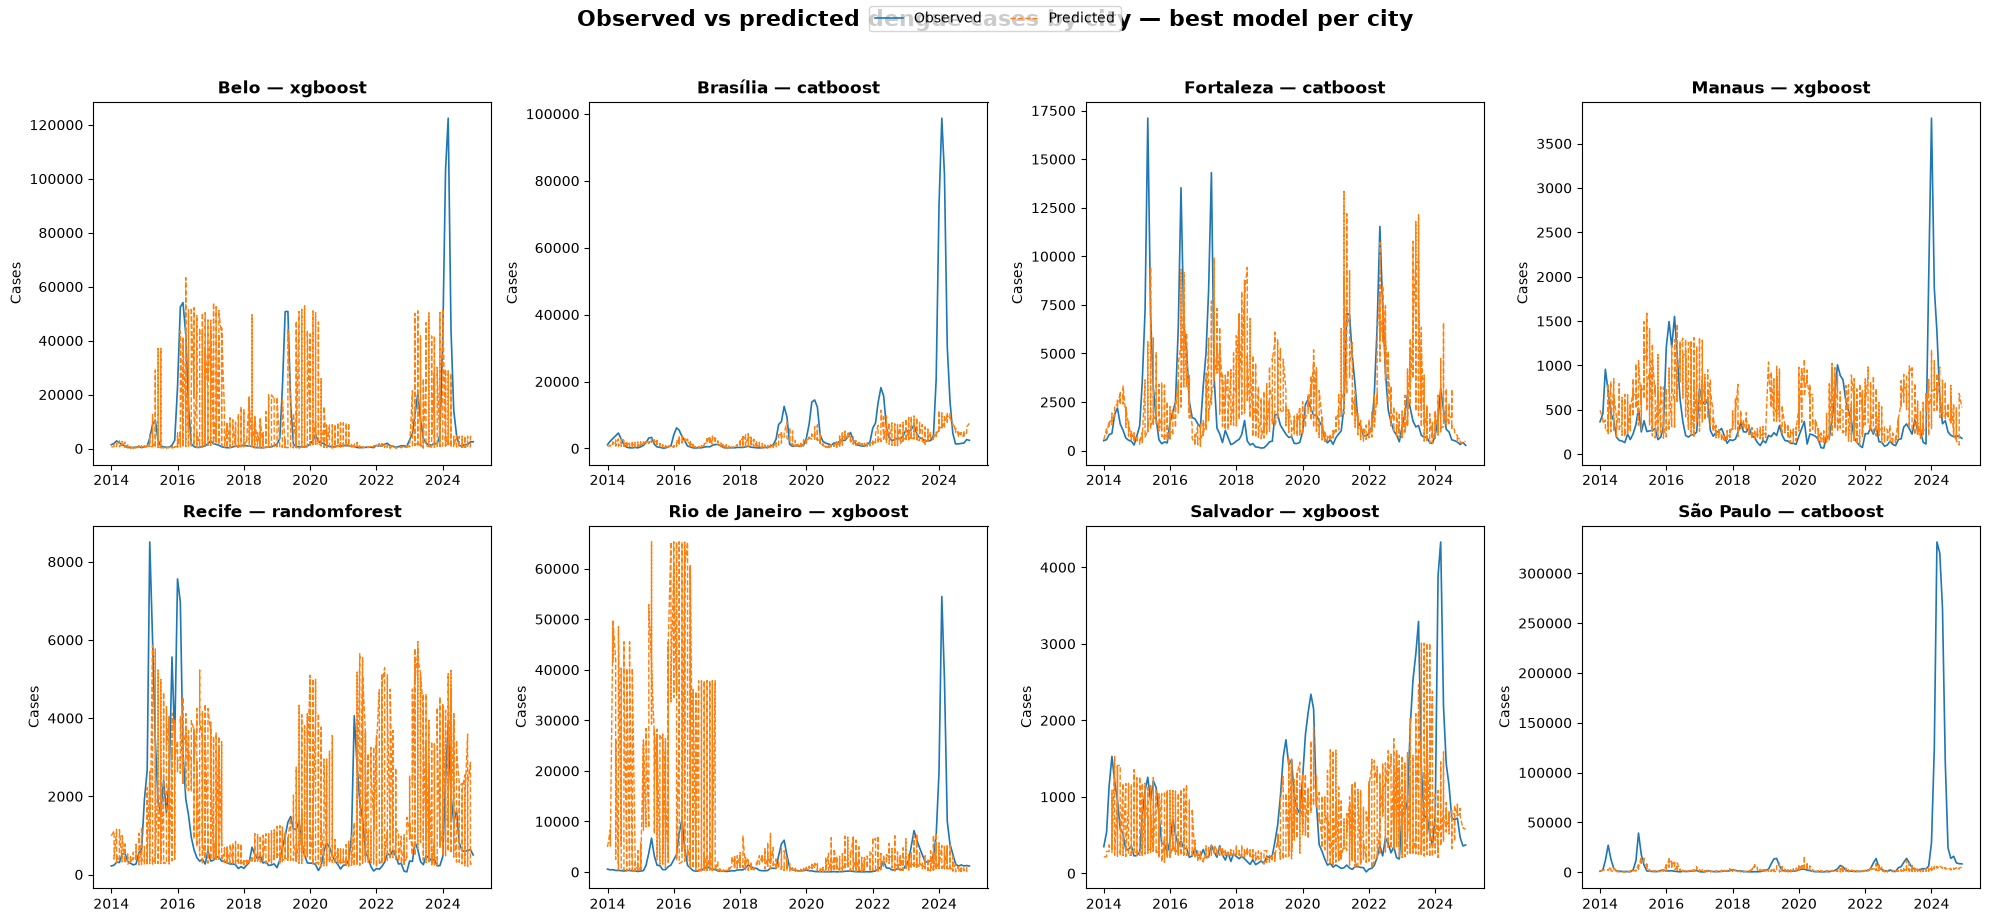

In [10]:
units = sorted(metrics_all["unit"].dropna().unique())

n_cols = 4
n_rows = int(np.ceil(len(units) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4.5 * n_rows), sharex=False)
axes = np.array(axes).reshape(-1)

for ax, unit in zip(axes, units):
    best_model = (
        metrics_all[metrics_all["unit"] == unit]
        .sort_values("sMAPE")
        .iloc[0]["model"]
    )

    sub = (
        preds_all[
            (preds_all["unit"] == unit) &
            (preds_all["model"] == best_model)
        ]
        .copy()
        .sort_values("date")
    )

    sub["date"] = pd.to_datetime(sub["date"])

    ax.plot(sub["date"], sub["y_true"], label="Observed", linewidth=1.2)
    ax.plot(sub["date"], sub["y_pred"], label="Predicted", linestyle="--", linewidth=1.0)
    ax.set_title(f"{unit} — {best_model}", fontweight="bold")
    ax.set_ylabel("Cases")

for ax in axes[len(units):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)

fig.suptitle("Observed vs predicted dengue cases by city — best model per city", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()

panel_path = FIGURES_DIR / "forecast_best_model_all_cities_panel.png"
plt.savefig(panel_path, dpi=300, bbox_inches="tight")
plt.show()

Agregação flexivel (permite juntar dinamicamente e ir iterando caso a caso)

In [11]:
def aggregate_series_registry(series_registry, level="region"):
    grouped = {}

    for city, info in series_registry.items():
        key = info[level]

        if key is None:
            continue

        if key not in grouped:
            grouped[key] = []

        grouped[key].append(info["series"].rename(city))

    aggregated = {}

    for key, series_list in grouped.items():
        df = pd.concat(series_list, axis=1).fillna(0)
        aggregated[key] = df.sum(axis=1).asfreq("MS")

    return aggregated


# Exemplo: benchmark por região
region_series = aggregate_series_registry(series_registry, level="region")

region_metrics = []
region_preds = []

for region_name, series in region_series.items():
    m, p = benchmark_series(
        series=series,
        unit_name=region_name,
        state=None,
        region=region_name,
        level="region",
    )
    region_metrics.append(m)
    region_preds.append(p)

region_metrics = pd.concat(region_metrics, ignore_index=True)
region_preds = pd.concat(region_preds, ignore_index=True)

region_metrics = region_metrics.rename(
    columns={
        "mae": "MAE",
        "rmse": "RMSE",
        "smape": "sMAPE",
        "n_predictions": "n_previsoes",
        "n_previsoes": "n_previsoes",
    }
)

region_metrics["rank_sMAPE"] = (
    region_metrics.groupby(["level", "unit"])["sMAPE"]
    .rank(method="min")
)

region_metrics.to_csv(TABLES_DIR / "model_performance_by_region.csv", index=False)
region_preds.to_csv(TABLES_DIR / "predictions_by_region.csv", index=False)

region_metrics.sort_values(["unit", "sMAPE"])

Rodando sarimax — Midwest
  [INFO] Rodando backtest para: sarimax
Rodando lgbm — Midwest
  [INFO] Rodando backtest para: lgbm
Rodando xgboost — Midwest
  [INFO] Rodando backtest para: xgboost
Rodando catboost — Midwest
  [INFO] Rodando backtest para: catboost
Rodando randomforest — Midwest
  [INFO] Rodando backtest para: randomforest
Rodando sarimax — Northeast
  [INFO] Rodando backtest para: sarimax
Rodando lgbm — Northeast
  [INFO] Rodando backtest para: lgbm
Rodando xgboost — Northeast
  [INFO] Rodando backtest para: xgboost
Rodando catboost — Northeast
  [INFO] Rodando backtest para: catboost
Rodando randomforest — Northeast
  [INFO] Rodando backtest para: randomforest
Rodando sarimax — North
  [INFO] Rodando backtest para: sarimax
Rodando lgbm — North
  [INFO] Rodando backtest para: lgbm
Rodando xgboost — North
  [INFO] Rodando backtest para: xgboost
Rodando catboost — North
  [INFO] Rodando backtest para: catboost
Rodando randomforest — North
  [INFO] Rodando backtest para: rando

,model,MAE,RMSE,sMAPE,n_previsoes,unit,state,region,level,rank_sMAPE
3,catboost,3886.819081,12393.197640,76.620848,1452,Midwest,None,Midwest,region,1.0
4,randomforest,4202.385110,12647.250729,82.384841,1452,Midwest,None,Midwest,region,2.0
2,xgboost,4196.149254,12678.425844,83.741951,1452,Midwest,None,Midwest,region,3.0
1,lgbm,4559.134172,12365.906937,100.549926,1452,Midwest,None,Midwest,region,4.0
0,sarimax,4481.896695,12356.601165,103.162274,1452,Midwest,None,Midwest,region,5.0
12,xgboost,324.298380,505.928031,65.481193,1452,North,None,North,region,1.0
14,randomforest,328.298044,505.844263,67.865818,1452,North,None,North,region,2.0
13,catboost,348.523485,541.731627,70.932050,1452,North,None,North,region,3.0
11,lgbm,523.883142,699.992036,94.803466,1452,North,None,North,region,4.0
10,sarimax,352.916742,604.632363,99.727284,1452,North,None,North,region,5.0
